In [1]:
# Cement

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings
from scipy.optimize import OptimizeWarning
warnings.simplefilter('ignore', OptimizeWarning)

from imagematerials.rest_of.resource_model import ResourceModel
from imagematerials.rest_of.const import (all_regions_list_class, models_output_dict)

In [3]:
# cement
cement = ResourceModel(resource_group = 'nmm', resource = 'cement', 
                       image_mat_available = True, start_year = 1971, 
                       scenario= 'SSP2_CP',
                       convert_image=True, end_year = 2012, convert_to_tons = 1/1000_000, 
                       trade_data=True)
# cement net trade
# Historical export per region for Cement (Mtonne), 1970-2000 + 2100 (constant from 2000 on) 
# (because export and import did not add up to 0, import has been increased by 25%, see Roorda, page 13)

china = ['class_ 20']

medium = ['class_ 1', 'class_ 2',  'class_ 3', 
        'class_ 5', 'class_ 6', 'class_ 10',
        'class_ 23',
        'class_ 11' , 'class_ 24'] 

# will get global fit
spreaded = ['class_ 12', 'class_ 16']

# what is in rest will be fitted to global fit      
rest = all_regions_list_class[:-1]
rest = [r for r in rest if r not in (china+medium)]

all_regions_list_class_except_china_and_global = [r for r in all_regions_list_class if r not in ['class_ 20', 'class_ 27']]

excluded = ['class_ 4', 'class_ 8', 'class_ 9', 'class_ 12']

# trajectory not to forseen, will be fitted with global regression

# for these models a regression will be made
# all reginos that are not in the high, medium, low will be fitted with the global regression
cement_grouping = {'all' : all_regions_list_class_except_china_and_global,
                    'china': china,
                    'medium': medium
                    }

cement.data_grouped_regions(regions_grouping = cement_grouping)

# get drivers for fitting (regions dont need to be summed, regions dict is none)
cement.sum_IMAGE_drivers_regions(regions_dict=None)

cement.match_MAT_data_to_regions_year(match_external_regions=False)



In [4]:
cement.image_mat_material_regions

,class_ 5,class_ 12,class_ 1,class_ 20,class_ 9,class_ 18,class_ 22,class_ 23,class_ 19,class_ 17,...,class_ 25.1,class_ 16.1,class_ 21.1,class_ 10.1,class_ 15.1,class_ 13.1,class_ 2.1,class_ 14.1,class_ 8.1,class_ 11.1
t,,,,,,,,,,,,,,,,,,,,,
1971,Concrete,Concrete,Concrete,Concrete,Concrete,Concrete,Concrete,Concrete,Concrete,Concrete,...,8.942400e+06,1.148073e+07,9.955920e+06,2.941487e+06,2.022276e+06,3.085002e+06,6.978066e+07,4.079563e+06,8.873030e+06,7.354371e+07
1972,Concrete,Concrete,Concrete,Concrete,Concrete,Concrete,Concrete,Concrete,Concrete,Concrete,...,3.831589e+06,7.385801e+06,7.222181e+06,1.247501e+06,1.557750e+06,4.111164e+06,9.769226e+07,2.433423e+06,6.985732e+06,9.121592e+07
1973,Concrete,Concrete,Concrete,Concrete,Concrete,Concrete,Concrete,Concrete,Concrete,Concrete,...,4.208604e+06,9.046891e+06,7.482508e+06,1.237733e+06,1.757846e+06,2.275839e+06,9.360269e+07,2.729264e+06,6.857271e+06,1.032718e+08
1974,Concrete,Concrete,Concrete,Concrete,Concrete,Concrete,Concrete,Concrete,Concrete,Concrete,...,8.325920e+06,8.703705e+06,7.117102e+06,1.270163e+06,1.826320e+06,2.872007e+06,2.225830e+07,2.826742e+06,7.311607e+06,6.277703e+07
1975,Concrete,Concrete,Concrete,Concrete,Concrete,Concrete,Concrete,Concrete,Concrete,Concrete,...,6.606318e+06,1.013437e+07,8.243655e+06,2.146173e+06,2.041835e+06,3.684217e+06,2.551543e+07,3.155761e+06,8.129096e+06,3.884508e+07
1976,Concrete,Concrete,Concrete,Concrete,Concrete,Concrete,Concrete,Concrete,Concrete,Concrete,...,7.307238e+06,1.111405e+07,9.147286e+06,2.706746e+06,1.993605e+06,5.031694e+06,1.128046e+08,3.253885e+06,8.238996e+06,9.940920e+07
1977,Concrete,Concrete,Concrete,Concrete,Concrete,Concrete,Concrete,Concrete,Concrete,Concrete,...,6.791264e+06,1.080371e+07,1.079748e+07,1.999965e+06,2.041874e+06,4.383509e+06,1.019318e+08,3.114921e+06,9.419127e+06,9.101191e+07
1978,Concrete,Concrete,Concrete,Concrete,Concrete,Concrete,Concrete,Concrete,Concrete,Concrete,...,9.481449e+06,1.081869e+07,1.078474e+07,1.102637e+06,2.188641e+06,3.312287e+06,1.253255e+08,3.085243e+06,7.714040e+06,8.659548e+07
1979,Concrete,Concrete,Concrete,Concrete,Concrete,Concrete,Concrete,Concrete,Concrete,Concrete,...,9.336896e+06,1.253997e+07,1.030388e+07,7.326741e+05,2.376292e+06,2.603116e+06,8.290128e+07,3.436324e+06,7.253844e+06,1.102205e+08


In [ ]:
cement.calculate_historic_other_fraction()

# deal with single negative numbers by removing them from dataset
cement.historic_other_fraction_consumption[cement.historic_other_fraction_consumption < 0] = np.nan

In [ ]:
# Fit models 
cement.calculate_regressors(cement.historic_other_fraction_consumption)

best_rmse_models={
    'all' : 'gompertz model',
    'china': 'gompertz model',
    'medium': 'gompertz model'}

bounds = {
    'all' : ([0, 0, 0], [10, 10, 10]),
    'china': ([0, 0, 0], [1.4, 10, 10]),
    'medium': ([0, 5, 0], [10, 10, 10]),
}

cement.fit_models(best_rmse_models, bounds)

# Best models
cement.best_rmse_models
cement.merged_rmse_r2

# project based on best model
cement.project_on_total(all_regions_list_class[:-1])

C:\Users\Arp00003\Coding\image-materials\imagematerials\rest_of\regression_models_classes.py:375: RuntimeWarning: divide by zero encountered in divide
  return a * np.exp(-((logX - b) ** 2) / (2 * c ** 2)) + d
C:\Users\Arp00003\Coding\image-materials\imagematerials\rest_of\regression_models_classes.py:375: RuntimeWarning: divide by zero encountered in divide
  return a * np.exp(-((logX - b) ** 2) / (2 * c ** 2)) + d
C:\Users\Arp00003\Coding\image-materials\imagematerials\rest_of\regression_models_classes.py:375: RuntimeWarning: divide by zero encountered in divide
  return a * np.exp(-((logX - b) ** 2) / (2 * c ** 2)) + d


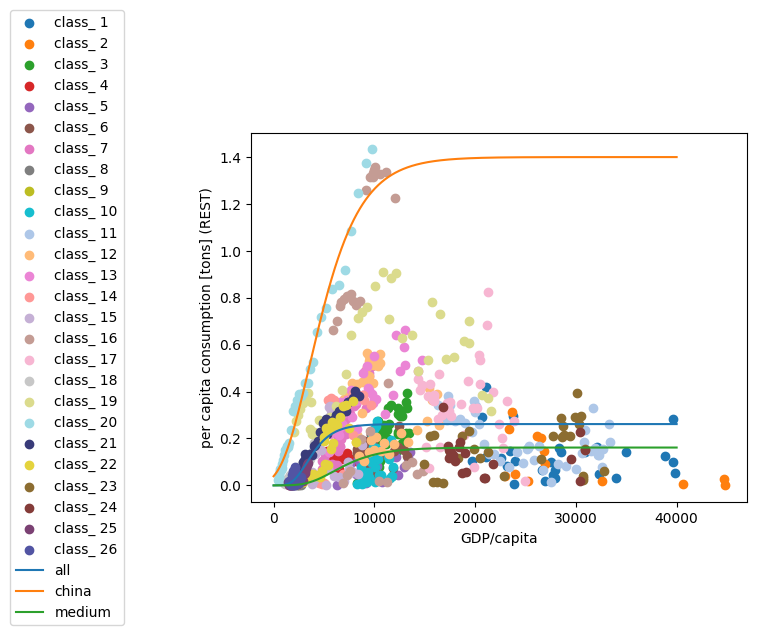

In [ ]:
# Plot regression with GDP/cap on x axis and cons/cap on y axis only for years that were fitted

colors = [
    '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
    '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf',
    '#aec7e8', '#ffbb78', "#EB85D5", '#ff9896', '#c5b0d5',
    '#c49c94', '#f7b6d2', '#c7c7c7', '#dbdb8d', '#9edae5',
    '#393b79', "#E4D33D", '#8c6d31', '#843c39', '#7b4173',
    '#5254a3'
]

# Create the mapping dictionary
color_dict = {f"class_ {i+1}": colors[i] for i in range(26)}

fig, ax = plt.subplots()             # Create a figure containing a single Axes.


for region in cement.cons_capita.columns:
    ax.scatter(cement.gdp_pc[region], 
               cement.cons_capita[region], 
               label = region,
               color = color_dict.get(region))
    
for grouping in cement_grouping.keys():
    model = cement.model_groups[grouping][models_output_dict[cement.best_rmse_models[grouping]]]
    ax.plot(model.predict(np.arange(1, 40001).reshape(-1, 1).astype(float)),
            label = grouping)

ax.set_ylabel("per capita consumption [tons] (REST)")
ax.set_xlabel("GDP/capita")

ax.legend(loc = 'center left', bbox_to_anchor=(-0.5, 0.5))


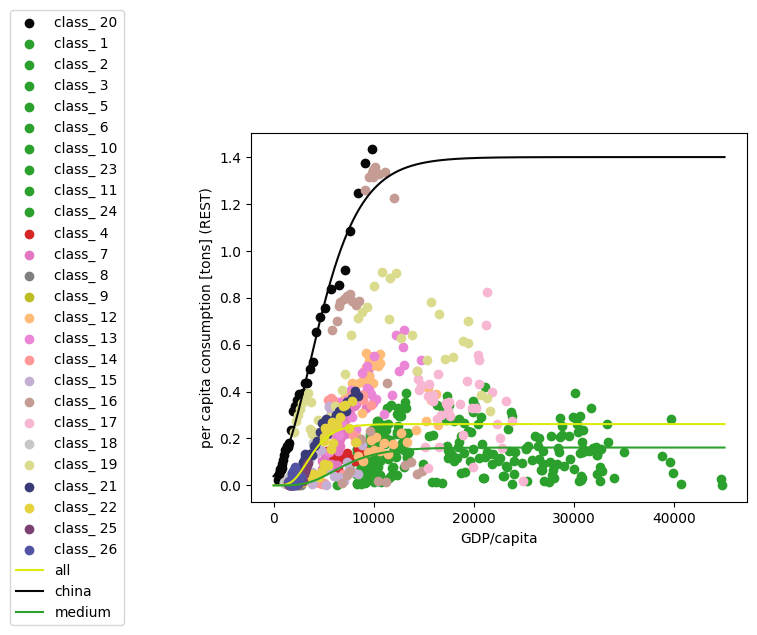

In [ ]:
# Grouping of regions for fitting

color_low_gdp = '#1f77b4'
color_low = "#b41f4c"
color_china = "#070707"
color_medium = '#2ca02c'

color_dict_fits = {
    'low_gdp': color_low_gdp,
    'low': color_low,
    'medium': color_medium,
    'china': color_china,
    'all': "#dceb0c",  # Color for all region
}


fig, ax = plt.subplots()             # Create a figure containing a single Axes.
    
for region in china:
    ax.scatter(cement.gdp_pc[region], 
               cement.cons_capita[region], 
               label = region,
               color = color_china)

for region in medium:
    ax.scatter(cement.gdp_pc[region], 
               cement.cons_capita[region], 
               label = region,
               color = color_medium)

for region in rest:
    ax.scatter(cement.gdp_pc[region], 
               cement.cons_capita[region], 
               label = region,
               color = color_dict.get(region))
    
for grouping in cement_grouping.keys():
    model = cement.model_groups[grouping][models_output_dict[cement.best_rmse_models[grouping]]]
    ax.plot(model.predict(np.arange(1, 45000).reshape(-1, 1)),
            label = grouping,
            color = color_dict_fits[grouping])

# set ax limits
ax.set_ylabel("per capita consumption [tons] (REST)")
ax.set_xlabel("GDP/capita")
ax.legend(loc = 'center left', bbox_to_anchor=(-0.5, 0.5))




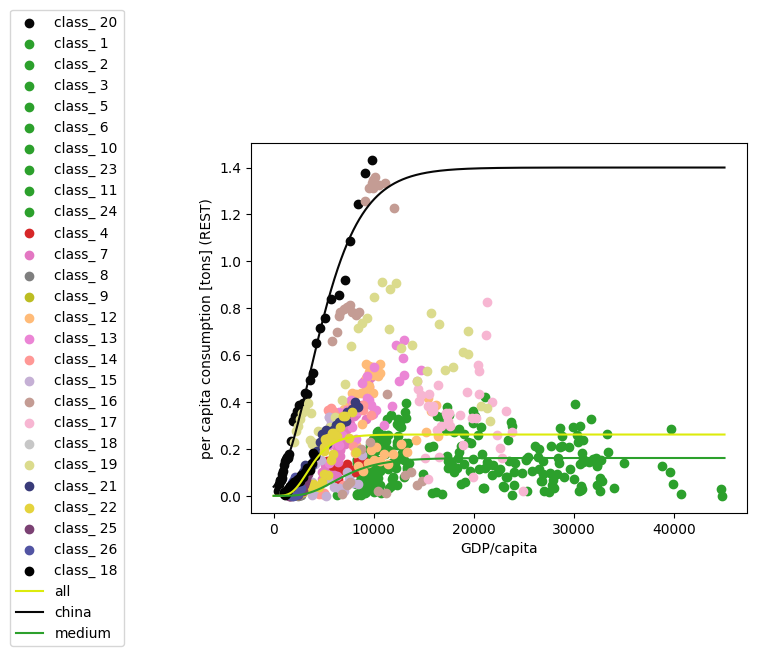

In [ ]:
# Grouping of regions for fitting

color_low_gdp = '#1f77b4'
color_low = "#b41f4c"
color_china = "#070707"
color_medium = '#2ca02c'

color_dict_fits = {
    'low_gdp': color_low_gdp,
    'low': color_low,
    'medium': color_medium,
    'china': color_china,
    'all': "#dceb0c",  # Color for all region
}


fig, ax = plt.subplots()             # Create a figure containing a single Axes.
    
for region in china:
    ax.scatter(cement.gdp_pc[region], 
               cement.cons_capita[region], 
               label = region,
               color = color_china)

for region in medium:
    ax.scatter(cement.gdp_pc[region], 
               cement.cons_capita[region], 
               label = region,
               color = color_medium)

for region in rest:
    ax.scatter(cement.gdp_pc[region], 
               cement.cons_capita[region], 
               label = region,
               color = color_dict.get(region))
    
for region in ["class_ 18"]:
    ax.scatter(cement.gdp_pc[region], 
               cement.cons_capita[region], 
               label = region,
               color = "black")
    
for grouping in cement_grouping.keys():
    model = cement.model_groups[grouping][models_output_dict[cement.best_rmse_models[grouping]]]
    ax.plot(model.predict(np.arange(1, 45000).reshape(-1, 1)),
            label = grouping,
            color = color_dict_fits[grouping])

# set ax limits
ax.set_ylabel("per capita consumption [tons] (REST)")
ax.set_xlabel("GDP/capita")
ax.legend(loc = 'center left', bbox_to_anchor=(-0.5, 0.5))




In [ ]:
cement.smooth_out_interpolation_all(10, 2012)

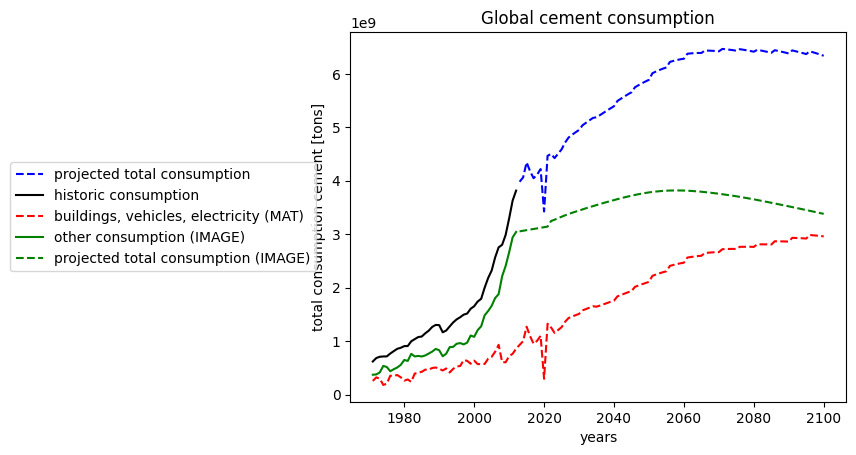

In [ ]:
fig, ax = plt.subplots()             # Create a figure containing a single Axes.

ax.plot(cement.projection_per_region_total.sum(axis = 1).loc[2013:] + cement.image_mat_data.sum(axis = 1).loc[2013:], 
        linestyle = '--', color = 'blue', label = 'projected total consumption')
ax.plot(cement.historic_consumption_data.sum(axis = 1),
        linestyle = '-', color = 'black', label = 'historic consumption')  

ax.plot(cement.image_mat_data.sum(axis = 1).loc[1971:],
        linestyle = '--', color = 'red', label = 'buildings, vehicles, electricity (MAT)')
ax.plot(cement.historic_other_fraction_consumption.sum(axis = 1),
        linestyle = '-', color = 'green', label = 'other consumption (IMAGE)')

ax.plot(cement.projection_per_region_total.loc[2013: ].sum(axis = 1),
        linestyle = '--', color = 'green', label = 'projected total consumption (IMAGE)')

ax.set_ylabel("total consumption cement [tons]")
ax.set_xlabel("years") 
ax.title.set_text("Global cement consumption")
ax.legend(loc = 'center left', bbox_to_anchor=(-0.7, 0.5))